# Warning and Error Count by Resource
Authenticate first, then run this notebook to query warning and error count by resource type.

## Import required libraries
This notebook uses shared helpers from the repository and standard data/plotting libraries to build warning and error count views.

In [1]:
from pathlib import Path
import sys
from datetime import datetime, timedelta, timezone

from google.api_core.exceptions import ResourceExhausted
import pandas as pd
import matplotlib.pyplot as plt
import time

repo_root = Path.cwd()
if not (repo_root / "src" / "helpers").exists():
    repo_root = repo_root.parent
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from helpers.logging_client import get_logs_client

## Create a client
Before running this notebook, authenticate with Application Default Credentials:
1. Run `gcloud auth application-default login`
2. Run `gcloud config set project <project-id>`
Then run the client cell below to connect to Cloud Logging.

In [2]:
logs = get_logs_client()

## Query the logs

Set one of these time window options:
- `lookback_hours` (for example `24`) to query the last N hours.
- or `start_timestamp` / `end_timestamp` in RFC3339 format (for example `2026-06-30T00:00:00Z`).

`max_results` is optional. Use `None` for no explicit cap.
The filter is scoped to WARNING and ERROR only to reduce read pressure while keeping full relevant results.

In [3]:
# Query options
lookback_hours = 6
start_timestamp = None  # Example: "2026-06-30T00:00:00Z"
end_timestamp = None  # Example: "2026-07-01T00:00:00Z"
max_results = None  # Set to None to remove explicit cap
page_size = 1000

if lookback_hours is not None and (start_timestamp is not None or end_timestamp is not None):
    raise ValueError("Use either lookback_hours or start/end timestamps, not both.")

if lookback_hours is not None:
    end_dt = datetime.now(timezone.utc)
    start_dt = end_dt - timedelta(hours=lookback_hours)
    start_timestamp = start_dt.isoformat().replace("+00:00", "Z")
    end_timestamp = end_dt.isoformat().replace("+00:00", "Z")

time_parts = []
if start_timestamp is not None:
    time_parts.append(f'timestamp>="{start_timestamp}"')
if end_timestamp is not None:
    time_parts.append(f'timestamp<="{end_timestamp}"')

time_clause = " AND ".join(time_parts) if time_parts else ""
severity_clause = '(severity="WARNING" OR severity="ERROR")'
log_filter = f"{severity_clause} AND {time_clause}" if time_clause else severity_clause

list_entries_kwargs = {
    "filter_": log_filter,
    "page_size": page_size,
}
if max_results is not None:
    list_entries_kwargs["max_results"] = max_results

print(f"Filter: {log_filter}")
print(f"max_results: {max_results}")
print(f"page_size: {page_size}")

Filter: (severity="WARNING" OR severity="ERROR") AND timestamp>="2026-07-01T09:09:44.818835Z" AND timestamp<="2026-07-01T15:09:44.818835Z"
max_results: None
page_size: 1000


Convert log entries to a flat list of fields used in this analysis.

In [4]:
entries = []
attempt = 0
max_attempts = 8
base_quota_cooldown_seconds = 65
inter_page_delay_seconds = 1.2  # ~50 page reads/minute max

while attempt < max_attempts:
    try:
        # Recreate the iterator on each attempt; list_entries results are one-pass.
        results = logs.list_entries(**list_entries_kwargs)

        entries = []
        page_count = 0
        entry_count = 0
        for result in results:
            entries.append(
                dict(
                    severity=result.severity,
                    timestamp=result.timestamp,
                    resource_type=result.resource.type,
                )
            )
            entry_count += 1

            # Approximate page-level throttling when iterating over the generator.
            if entry_count % page_size == 0:
                page_count += 1
                time.sleep(inter_page_delay_seconds)

        if entry_count % page_size != 0 and entry_count > 0:
            page_count += 1

        print(f"Fetched pages (approx): {page_count}")
        break
    except ResourceExhausted as exc:
        attempt += 1
        if attempt >= max_attempts:
            raise
        wait_seconds = max(base_quota_cooldown_seconds, 2**attempt)
        print(
            f"Read quota hit (attempt {attempt}/{max_attempts - 1}), "
            f"retrying in {wait_seconds}s..."
        )
        print(str(exc).splitlines()[0])
        time.sleep(wait_seconds)

print(f"Fetched entries: {len(entries)}")

Fetched pages (approx): 15
Fetched entries: 14746


## Prepare analysis data
Load the extracted entries into a DataFrame.

In [5]:
entries_df = pd.DataFrame(entries, columns=["severity", "timestamp", "resource_type"])

In [6]:
entries_df

,severity,timestamp,resource_type
0,WARNING,2026-07-01 09:09:50+00:00,gce_instance
1,WARNING,2026-07-01 09:09:50.572764+00:00,http_load_balancer
2,WARNING,2026-07-01 09:09:50.632861+00:00,http_load_balancer
3,WARNING,2026-07-01 09:10:05+00:00,gce_instance
4,ERROR,2026-07-01 09:10:05+00:00,gce_instance
...,...,...,...
14741,WARNING,2026-07-01 15:08:20+00:00,gce_instance
14742,WARNING,2026-07-01 15:08:20.788428+00:00,gce_instance
14743,WARNING,2026-07-01 15:08:20.857823+00:00,gce_instance
14744,WARNING,2026-07-01 15:08:53.351419+00:00,http_load_balancer


Aggregate warning and error counts by resource type.

In [7]:
severity_by_resource = (
    entries_df[entries_df["severity"].isin(["WARNING", "ERROR"])]
    .groupby(["resource_type", "severity"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["WARNING", "ERROR"], fill_value=0)
)

In [8]:
severity_by_resource

severity,WARNING,ERROR
resource_type,,
audited_resource,0,250
cloud_run_revision,55,1
gae_app,88,19
gce_backend_service,0,79
gce_instance,3477,2987
gcs_bucket,0,6
http_load_balancer,7783,0
metric,0,1


## Plot warning and error charts
The first chart shows warning counts and the second chart shows error counts by resource type.

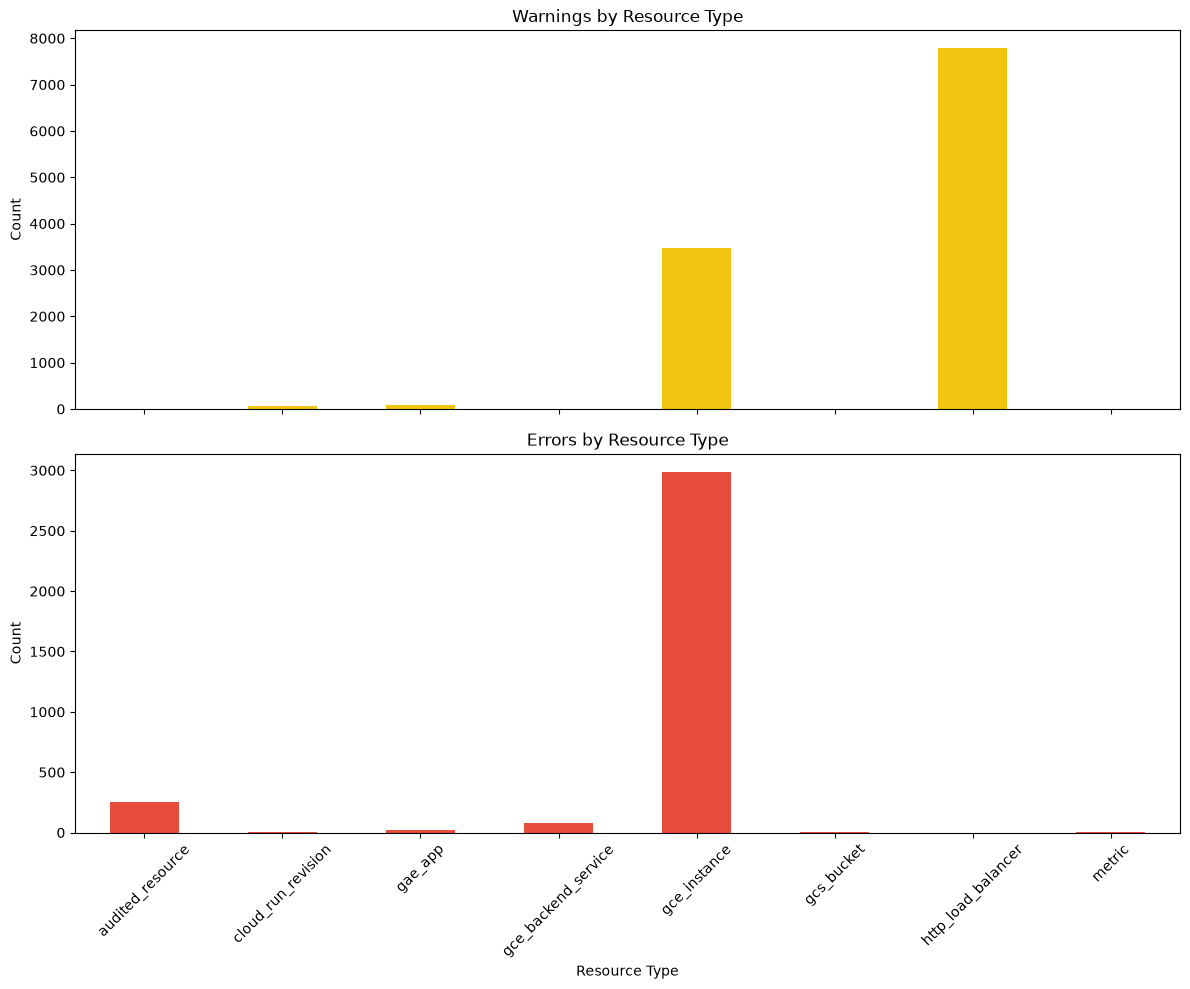

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

if severity_by_resource.empty:
    for ax in axes:
        ax.text(
            0.5,
            0.5,
            "No WARNING/ERROR entries found for the selected filters.",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        ax.set_axis_off()
else:
    severity_by_resource["WARNING"].plot(
        kind="bar",
        color="#f1c40f",
        ax=axes[0],
    )
    axes[0].set_title("Warnings by Resource Type")
    axes[0].set_ylabel("Count")
    axes[0].set_xlabel("Resource Type")

    severity_by_resource["ERROR"].plot(
        kind="bar",
        color="#e74c3c",
        ax=axes[1],
    )
    axes[1].set_title("Errors by Resource Type")
    axes[1].set_ylabel("Count")
    axes[1].set_xlabel("Resource Type")

    for ax in axes:
        ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()